## TASK 2: PRODUCT CATEGORY CLUSTERING

Goal:
    Group Amazon products into 4–6 meaningful meta-categories
    using unsupervised machine learning.

Approach:
    1. Load the preprocessed review dataset
    2. Aggregate reviews at product/ASIN level
    3. Build textual product representations
    4. Convert text to TF-IDF features
    5. Compare K-Means models for K = 4, 5, 6
    6. Evaluate clusters using:
          - Silhouette Score
          - Davies-Bouldin Score
    7. Inspect cluster keywords and products
    8. Assign meaningful meta-category names
    9. Attach the meta-category back to every review
    10. Save the final clustered dataset

In [ ]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.sparse import hstack

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 100)

## Loading the preprocessed data we get from task 1: Sentiments analysis

In [3]:
# Load the output of Task 1, i.e: customer reviews 

df = pd.read_csv("../data/processed/customer_reviews_processed.csv")
print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (34614, 14)


,product_name,asins,brand,categories,manufacturer,reviews.date,reviews.doRecommend,reviews.numHelpful,reviews.rating,reviews.title,reviews.text,clean_text,sentiment,text_length
0,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Tablets,Tablets,Computers & Tablets",Amazon,2017-01-13 00:00:00+00:00,yes,0.0,5,Kindle,This product so far has not disappointed. My children love to use it and I like the ability to m...,this product so far has not disappointed. my children love to use it and i like the ability to m...,positive,143
1,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Tablets,Tablets,Computers & Tablets",Amazon,2017-01-13 00:00:00+00:00,yes,0.0,5,very fast,great for beginner or experienced person. Bought as a gift and she loves it,great for beginner or experienced person. bought as a gift and she loves it,positive,75
2,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Tablets,Tablets,Computers & Tablets",Amazon,2017-01-13 00:00:00+00:00,yes,0.0,5,Beginner tablet for our 9 year old son.,"Inexpensive tablet for him to use and learn on, step up from the NABI. He was thrilled with it, ...","inexpensive tablet for him to use and learn on, step up from the nabi. he was thrilled with it, ...",positive,131
3,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Tablets,Tablets,Computers & Tablets",Amazon,2017-01-13 00:00:00+00:00,yes,0.0,4,Good!!!,I've had my Fire HD 8 two weeks now and I love it. This tablet is a great value.We are Prime Mem...,i've had my fire hd 8 two weeks now and i love it. this tablet is a great value.we are prime mem...,positive,593
4,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Tablets,Tablets,Computers & Tablets",Amazon,2017-01-12 00:00:00+00:00,yes,0.0,5,Fantastic Tablet for kids,I bought this for my grand daughter when she comes over to visit. I set it up with her as the us...,i bought this for my grand daughter when she comes over to visit. i set it up with her as the us...,positive,613


In [4]:
# Inspect the available columns
print("Columns:")
for column in df.columns:
    print("-", column)

Columns:
- product_name
- asins
- brand
- categories
- manufacturer
- reviews.date
- reviews.doRecommend
- reviews.numHelpful
- reviews.rating
- reviews.title
- reviews.text
- clean_text
- sentiment
- text_length


## Basic Product level Analysis

In [6]:
print("Number of reviews:", len(df))
print("Number of unique ASIN groups:", df["asins"].nunique())
print("Number of unique product names:", df["product_name"].nunique())
print("Number of brands:", df["brand"].nunique())
print("Number of manufacturers:", df["manufacturer"].nunique())

Number of reviews: 34614
Number of unique ASIN groups: 39
Number of unique product names: 49
Number of brands: 5
Number of manufacturers: 2


In [7]:
clustering_columns = [
    "product_name",
    "asins",
    "brand",
    "categories",
    "manufacturer",
    "clean_text"
]

for column in clustering_columns:
    df[column] = df[column].fillna("").astype(str)

# Clean the fields used for clustering

In [8]:
clustering_columns = [
    "product_name",
    "asins",
    "brand",
    "categories",
    "manufacturer",
    "clean_text"
]

for column in clustering_columns:
    df[column] = df[column].fillna("").astype(str)

# Remove unknown product Id before clustering

In [10]:
unknown_asins = df[
    (df["asins"].str.strip() == "") |
    (df["asins"].str.lower() == "unknown")
]

print("Reviews with missing/unknown ASIN:",
      len(unknown_asins)) 

# keep only records with a usable ASIN:
df_cluster = df[
    (df["asins"].str.strip() != "") &
    (df["asins"].str.lower() != "unknown")
].copy()

print("Reviews used for clustering:", len(df_cluster))

Reviews with missing/unknown ASIN: 2
Reviews used for clustering: 34612


## Build Product level data set for clustering

In [11]:
# Work on a copy
df_cluster = df.copy()

# Clean important columns

cluster_columns = [
    "asins",
    "product_name",
    "categories",
    "brand",
    "manufacturer",
    "clean_text"
]

for col in cluster_columns:
    if col not in df_cluster.columns:
        df_cluster[col] = ""

    df_cluster[col] = (
        df_cluster[col]
        .fillna("")
        .astype(str)
        .str.strip()
    )

# Normalize ASIN

df_cluster["asin_clean"] = (
    df_cluster["asins"]
    .str.upper()
    .str.replace(r"[\[\]'\" ]", "", regex=True)
)

# Identify valid ASINs

invalid_asins = [
    "",
    "UNKNOWN",
    "NAN",
    "NONE",
    "NULL",
    "NA"
]

df_cluster["valid_asin"] = (
    ~df_cluster["asin_clean"].isin(invalid_asins)
)

print("Total reviews:", len(df_cluster))
print("Reviews with valid ASIN:", df_cluster["valid_asin"].sum())
print("Reviews without valid ASIN:", (~df_cluster["valid_asin"]).sum())

Total reviews: 34614
Reviews with valid ASIN: 34612
Reviews without valid ASIN: 2


## CELL 9: CREATE CLEAN PRODUCT IDENTIFIER

In [12]:

# Normalize product name for fallback identification
df_cluster["product_name_clean"] = (
    df_cluster["product_name"]
    .str.lower()
    .str.replace(r"[^a-z0-9]+", " ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

# Use ASIN whenever available.
# If ASIN is missing, use normalized product name.
df_cluster["product_id"] = np.where(
    df_cluster["valid_asin"],
    "ASIN_" + df_cluster["asin_clean"],
    "NAME_" + df_cluster["product_name_clean"]
)

# Remove completely unidentified products
df_cluster = df_cluster[
    ~df_cluster["product_id"].isin([
        "NAME_",
        "NAME_unknown",
        "NAME_nan",
        "NAME_none"
    ])
].copy()

print("Unique product identifiers:", df_cluster["product_id"].nunique())
print("Reviews retained:", len(df_cluster))

Unique product identifiers: 39
Reviews retained: 34614


## Aggregate reviews to product level

In [13]:
# CELL 10: AGGREGATE TO PRODUCT LEVEL

MAX_REVIEWS_PER_PRODUCT = 100

def combine_reviews(series):

    series = series.dropna().astype(str)

    series = series[
        series.str.strip() != ""
    ]

    # Prevent products with huge numbers of reviews
    # from dominating the clustering
    if len(series) > MAX_REVIEWS_PER_PRODUCT:
        series = series.sample(
            MAX_REVIEWS_PER_PRODUCT,
            random_state=42
        )

    return " ".join(series)


product_df = (
    df_cluster
    .groupby("product_id")
    .agg(
        asin=("asin_clean", "first"),
        product_name=("product_name", "first"),
        categories=(
            "categories",
            lambda x: " ".join(
                pd.unique(
                    x[x.str.strip() != ""]
                )
            )
        ),
        brand=("brand", "first"),
        manufacturer=("manufacturer", "first"),
        review_text=("clean_text", combine_reviews),
        n_reviews=("clean_text", "size")
    )
    .reset_index()
)

print("Number of unique products:", len(product_df))
print("Total reviews represented:", product_df["n_reviews"].sum())

Number of unique products: 39
Total reviews represented: 34614


# Check the Cleaned Product data

In [41]:
# CELL 11: CHECK PRODUCT DATA

print("\nProduct-level dataset:")
print("=" * 60)

print(product_df.head(10).to_string(index=False))

print("\nDuplicate product IDs:")
print(product_df["product_id"].duplicated().sum())

print("\nMissing product names:")
print(
    (product_df["product_name"].str.strip() == "").sum()
)

print("\nProducts with valid ASIN:")
print(
    (~product_df["asin"].isin(["", "UNKNOWN", "NAN"])).sum()
)


Product-level dataset:
                product_id                  asin                                                                                                                                  product_name                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            categories                        brand                 manufacturer  

## CREATE PRODUCT METADATA TEXT

In [16]:
# CELL 12: CREATE PRODUCT METADATA TEXT

product_df["metadata_text"] = (
    product_df["product_name"] + " "
    + product_df["product_name"] + " "
    + product_df["categories"] + " "
    + product_df["brand"] + " "
    + product_df["manufacturer"]
)

product_df["metadata_text"] = (
    product_df["metadata_text"]
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

print(product_df[
    ["product_name", "metadata_text"]
].head(5).to_string(index=False))

                                                                    product_name                                                                                                                                                                                                                                                                                                                                                  metadata_text
                                                                         Unknown                                                                                                                                                              Unknown Unknown Electronics,Amazon Device Accessories,Kindle Store,Covers,Kindle E-Reader Accessories,Kindle DX (2nd Generation, Global Wireless) Accessories Amazon Digital Services Inc. Amazon
Amazon Kindle Lighted Leather Cover,,,\r\nAmazon Kindle Lighted Leather Cover,,, Amazon Kindle Lighted Leather Cover,,, Amazon Kindle Li

## TF-IDF and dimensionality reduction

In [42]:
# CELL 13: TF-IDF FEATURE ENGINEERING

from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer

# Metadata TF-IDF
# ------------------------------------------------------------

metadata_vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=1,
    max_df=0.95,
    sublinear_tf=True,
    max_features=30000
)

X_metadata = metadata_vectorizer.fit_transform(
    product_df["metadata_text"]
)

# ------------------------------------------------------------
# Review TF-IDF
# ------------------------------------------------------------

review_vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    max_features=30000
)

X_reviews = review_vectorizer.fit_transform(
    product_df["review_text"]
)

# ------------------------------------------------------------
# Give metadata more importance than review wording
# ------------------------------------------------------------

METADATA_WEIGHT = 3.0
REVIEW_WEIGHT = 0.5

X = hstack([
    X_metadata * METADATA_WEIGHT,
    X_reviews * REVIEW_WEIGHT
]).tocsr()

print("Metadata features:", X_metadata.shape[1])
print("Review features:", X_reviews.shape[1])
print("Combined feature matrix:", X.shape)

Metadata features: 672
Review features: 4656
Combined feature matrix: (39, 5328)


In [19]:
# CELL 14: Reduce Dimensions

n_components = min(
    30,
    X.shape[0] - 1,
    X.shape[1] - 1
)

svd = TruncatedSVD(
    n_components=n_components,
    random_state=42
)

X_reduced = svd.fit_transform(X)

normalizer = Normalizer()

X_reduced = normalizer.fit_transform(
    X_reduced
)

print("Reduced feature matrix:", X_reduced.shape)
print(
    "Explained variance:",
    round(svd.explained_variance_ratio_.sum(), 4)
)

Reduced feature matrix: (39, 30)
Explained variance: 0.9598


In [23]:
# CELL 15: COMPARE K = 4, 5, 6

from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score
)

results = []
models = {}

for k in [4, 5, 6]:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=30,
        max_iter=500
    )

    labels = kmeans.fit_predict(X_reduced)

    silhouette = silhouette_score(
        X_reduced,
        labels
    )

    davies_bouldin = davies_bouldin_score(
        X_reduced,
        labels
    )

    results.append({
        "K": k,
        "Silhouette Score": round(silhouette, 4),
        "Davies-Bouldin Score": round(davies_bouldin, 4)
    })

    models[k] = kmeans

results_df = pd.DataFrame(results)

print("\nClustering Model Comparison")
print("=" * 60)

print(
    results_df.to_string(index=False)
)


Clustering Model Comparison
 K  Silhouette Score  Davies-Bouldin Score
 4            0.1886                2.1180
 5            0.2039                1.8172
 6            0.2160                1.7021


In [40]:
# CELL 16: SELECT FINAL NUMBER OF CLUSTERS

BEST_K = 6

print("Selected number of clusters:", BEST_K)

print("\nReason:")
print("- K=6 has the highest Silhouette Score: 0.2160.")
print("- K=6 has the lowest Davies-Bouldin Score: 1.7021.")
print("- Therefore, K=6 provides the best separation among the tested models.")

Selected number of clusters: 6

Reason:
- K=6 has the highest Silhouette Score: 0.2160.
- K=6 has the lowest Davies-Bouldin Score: 1.7021.
- Therefore, K=6 provides the best separation among the tested models.


## Train final K-Means model

In [25]:
# CELL 17: FINAL K-MEANS MODEL

final_kmeans = KMeans(
    n_clusters=BEST_K,
    random_state=42,
    n_init=30,
    max_iter=500
)

product_df["cluster"] = final_kmeans.fit_predict(
    X_reduced
)

print("Final clustering completed.")

Final clustering completed.


In [26]:
# CELL 18: CLUSTER SIZE SUMMARY

cluster_size = (
    product_df
    .groupby("cluster")
    .agg(
        Products=("product_id", "nunique"),
        Reviews=("n_reviews", "sum")
    )
    .reset_index()
)

print("\nCluster Size Summary")
print("=" * 60)

print(
    cluster_size.to_string(index=False)
)


Cluster Size Summary
 cluster  Products  Reviews
       0         6     1104
       1         3     1696
       2         6      855
       3        13    18109
       4         7      532
       5         4    12318


## Top keywords and products

In [27]:
# CELL 19: TOP KEYWORDS AND EXAMPLE PRODUCTS

feature_names = metadata_vectorizer.get_feature_names_out()

metadata_dense = X_metadata.toarray()

for cluster_id in sorted(product_df["cluster"].unique()):

    print("\n" + "=" * 80)
    print(f"CLUSTER: {cluster_id}")
    print("=" * 80)

    # --------------------------------------------------------
    # Products in this cluster
    # --------------------------------------------------------

    cluster_mask = (
        product_df["cluster"].values == cluster_id
    )

    cluster_matrix = metadata_dense[
        cluster_mask
    ]

    # Mean TF-IDF for the cluster
    mean_tfidf = cluster_matrix.mean(axis=0)

    top_indices = mean_tfidf.argsort()[-10:][::-1]

    top_keywords = [
        feature_names[i]
        for i in top_indices
    ]

    print("\nTop keywords:")
    print(", ".join(top_keywords))

    # --------------------------------------------------------
    # Example products
    # --------------------------------------------------------

    examples = product_df[
        product_df["cluster"] == cluster_id
    ]["product_name"].drop_duplicates()

    print("\nExample products:")

    for product in examples.head(10):
        print("-", product)


CLUSTER: 0

Top keywords:
ips display, kindle 16gb, new amazon, brand new, 16gb, gb blue, wifi 16, wifi, 16gb ips, blue

Example products:
- Brand New Amazon Kindle Fire 16gb 7 Ips Display Tablet Wifi 16 Gb Blue,,,

CLUSTER: 1

Top keywords:
edition tablet, green, kid proof, green kid, case, edition, kid, proof case, proof, gb green

Example products:
- Amazon Kindle Lighted Leather Cover,,,
Amazon Kindle Lighted Leather Cover,,,
- Fire Kids Edition Tablet, 7 Display, Wi-Fi, 16 GB, Green Kid-Proof Case

CLUSTER: 2

Top keywords:
white, echo white, tablets, echo, white echo, tablets tablets, computers, computers tablets, tablets computers, unknown

Example products:
- Echo (White),,,
Echo (White),,,
- Amazon Kindle Fire Hd (3rd Generation) 8gb,,,
Amazon Kindle Fire Hd (3rd Generation) 8gb,,,
- Unknown

CLUSTER: 3

Top keywords:
special, special offers, offers, includes special, includes, wi fi, wi, fi, gb includes, display wi

Example products:
- Kindle Voyage E-reader, 6 High-Resoluti

In [29]:
# CELL 20: DETAILED CLUSTER SUMMARY

cluster_details = []

for cluster_id in sorted(product_df["cluster"].unique()):

    cluster_products = product_df[
        product_df["cluster"] == cluster_id
    ]

    # Get top keywords
    cluster_mask = (
        product_df["cluster"].values == cluster_id
    )

    cluster_matrix = metadata_dense[
        cluster_mask
    ]

    mean_tfidf = cluster_matrix.mean(axis=0)

    top_indices = mean_tfidf.argsort()[-8:][::-1]

    top_keywords = [
        feature_names[i]
        for i in top_indices
    ]

    # Example products
    examples = (
        cluster_products["product_name"]
        .drop_duplicates()
        .head(3)
        .tolist()
    )

    cluster_details.append({
        "Cluster": cluster_id,
        "Products": cluster_products["product_id"].nunique(),
        "Reviews": cluster_products["n_reviews"].sum(),
        "Top Keywords": ", ".join(top_keywords),
        "Example Products": " | ".join(examples)
    })

cluster_details_df = pd.DataFrame(
    cluster_details
)

print(
    cluster_details_df.to_string(index=False)
)

 Cluster  Products  Reviews                                                                                Top Keywords                                                                                                                                                                                                                                                                                                                 Example Products
       0         6     1104               ips display, kindle 16gb, new amazon, brand new, 16gb, gb blue, wifi 16, wifi                                                                                                                                                                                                                                                        Brand New Amazon Kindle Fire 16gb 7 Ips Display Tablet Wifi 16 Gb Blue,,,
       1         3     1696                 edition tablet, green, kid proof, green kid, case, edition, kid, proof cas

## Assign Meta-Category meaningful Names

In [31]:
# CELL 21: Assign Meta-Category Names

cluster_names = {
    0: "Kindle Fire Tablets – 16GB",
    1: "Fire Kids Edition Tablets & Accessories",
    2: "Echo & Kindle Fire Devices",
    3: "Kindle & Fire Devices – Special Offers",
    4: "Amazon Device Accessories & Chargers",
    5: "Echo & Smart Home Devices"
}

# Map cluster numbers to meaningful names
product_df["meta_category"] = product_df["cluster"].map(cluster_names)

# Display the mapping
print("Cluster → Meta-category mapping")
print("=" * 60)

display(
    product_df[["cluster", "meta_category"]]
    .drop_duplicates()
    .sort_values("cluster")
)

Cluster → Meta-category mapping


,cluster,meta_category
5,0,Kindle Fire Tablets – 16GB
1,1,Fire Kids Edition Tablets & Accessories
16,2,Echo & Kindle Fire Devices
6,3,Kindle & Fire Devices – Special Offers
0,4,Amazon Device Accessories & Chargers
8,5,Echo & Smart Home Devices


## Final product-category table

In [33]:
# CELL 22 — Final Meta-Category Summary

meta_summary = (
    product_df.groupby("meta_category")
    .agg(
        Products=("product_id", "nunique"),
        Reviews=("n_reviews", "sum")
    )
    .reset_index()
)

meta_summary = meta_summary.sort_values(
    "Reviews",
    ascending=False
).reset_index(drop=True)

print("Final Meta-Category Summary")
print("=" * 80)
print(meta_summary.to_string(index=False))

Final Meta-Category Summary
                          meta_category  Products  Reviews
 Kindle & Fire Devices – Special Offers        13    18109
              Echo & Smart Home Devices         4    12318
Fire Kids Edition Tablets & Accessories         3     1696
             Kindle Fire Tablets – 16GB         6     1104
             Echo & Kindle Fire Devices         6      855
   Amazon Device Accessories & Chargers         7      532


## Add Cluster Information Back to Reviews

In [34]:
# CELL 23: Add Cluster Information Back to Reviews

cluster_info = product_df[
    ["product_id", "cluster", "meta_category"]
].copy()

df_clustered = df_cluster.merge(
    cluster_info,
    on="product_id",
    how="left"
)

print("Final clustered dataset shape:")
print(df_clustered.shape)

print("\nCluster distribution:")
print(
    df_clustered["cluster"]
    .value_counts()
    .sort_index()
)

print("\nMeta-category distribution:")
print(
    df_clustered["meta_category"]
    .value_counts()
)

print("\nSample of final dataset:")
display(
    df_clustered[
        [
            "product_name",
            "product_id",
            "cluster",
            "meta_category",
            "sentiment"
        ]
    ].head(10)
)

Final clustered dataset shape:
(34614, 20)

Cluster distribution:
cluster
0     1104
1     1696
2      855
3    18109
4      532
5    12318
Name: count, dtype: int64

Meta-category distribution:
meta_category
Kindle & Fire Devices – Special Offers     18109
Echo & Smart Home Devices                  12318
Fire Kids Edition Tablets & Accessories     1696
Kindle Fire Tablets – 16GB                  1104
Echo & Kindle Fire Devices                   855
Amazon Device Accessories & Chargers         532
Name: count, dtype: int64

Sample of final dataset:


,product_name,product_id,cluster,meta_category,sentiment
0,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta",ASIN_B01AHB9CN2,3,Kindle & Fire Devices – Special Offers,positive
1,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta",ASIN_B01AHB9CN2,3,Kindle & Fire Devices – Special Offers,positive
2,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta",ASIN_B01AHB9CN2,3,Kindle & Fire Devices – Special Offers,positive
3,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta",ASIN_B01AHB9CN2,3,Kindle & Fire Devices – Special Offers,positive
4,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta",ASIN_B01AHB9CN2,3,Kindle & Fire Devices – Special Offers,positive
5,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta",ASIN_B01AHB9CN2,3,Kindle & Fire Devices – Special Offers,positive
6,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta",ASIN_B01AHB9CN2,3,Kindle & Fire Devices – Special Offers,positive
7,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta",ASIN_B01AHB9CN2,3,Kindle & Fire Devices – Special Offers,positive
8,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta",ASIN_B01AHB9CN2,3,Kindle & Fire Devices – Special Offers,positive
9,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta",ASIN_B01AHB9CN2,3,Kindle & Fire Devices – Special Offers,positive


In [35]:
# CELL 23 — Add Cluster Information to Review Dataset

cluster_info = product_df[
    ["product_id", "cluster", "meta_category"]
].copy()

df_clustered = df_cluster.merge(
    cluster_info,
    on="product_id",
    how="left"
)

print("Final clustered dataset shape:")
print(df_clustered.shape)

print("\nCluster distribution:")
print(df_clustered["cluster"].value_counts().sort_index())

print("\nMeta-category distribution:")
print(df_clustered["meta_category"].value_counts())

print("\nSample of final dataset:")
print(
    df_clustered[
        [
            "product_name",
            "product_id",
            "cluster",
            "meta_category",
            "sentiment"
        ]
    ].head(10).to_string(index=False)
)

Final clustered dataset shape:
(34614, 20)

Cluster distribution:
cluster
0     1104
1     1696
2      855
3    18109
4      532
5    12318
Name: count, dtype: int64

Meta-category distribution:
meta_category
Kindle & Fire Devices – Special Offers     18109
Echo & Smart Home Devices                  12318
Fire Kids Edition Tablets & Accessories     1696
Kindle Fire Tablets – 16GB                  1104
Echo & Kindle Fire Devices                   855
Amazon Device Accessories & Chargers         532
Name: count, dtype: int64

Sample of final dataset:
                                                                           product_name      product_id  cluster                          meta_category sentiment
All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta ASIN_B01AHB9CN2        3 Kindle & Fire Devices – Special Offers  positive
All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta ASIN_B01AHB9CN2        3 Kindle &

In [36]:
# CELL 24 — Save Final Clustered Dataset

output_file = "../data/processed/customer_reviews_product_clustered.csv"

df_clustered.to_csv(output_file, index=False)

print(f"Saved successfully: {output_file}")
print(f"Rows: {len(df_clustered):,}")
print(f"Columns: {len(df_clustered.columns)}")

Saved successfully: ../data/processed/customer_reviews_product_clustered.csv
Rows: 34,614
Columns: 20


## Visualization

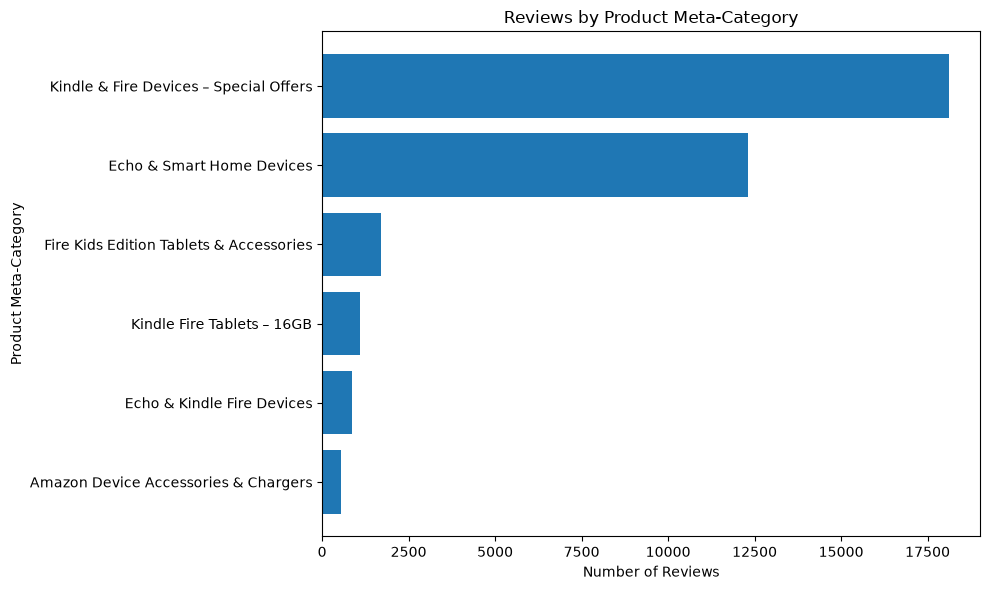

In [37]:
# GRAPH 1 — Reviews by Product Meta-Category

import matplotlib.pyplot as plt

category_counts = (
    df_clustered["meta_category"]
    .value_counts()
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 6))

plt.barh(
    category_counts.index,
    category_counts.values
)

plt.xlabel("Number of Reviews")
plt.ylabel("Product Meta-Category")
plt.title("Reviews by Product Meta-Category")

plt.tight_layout()
plt.show()

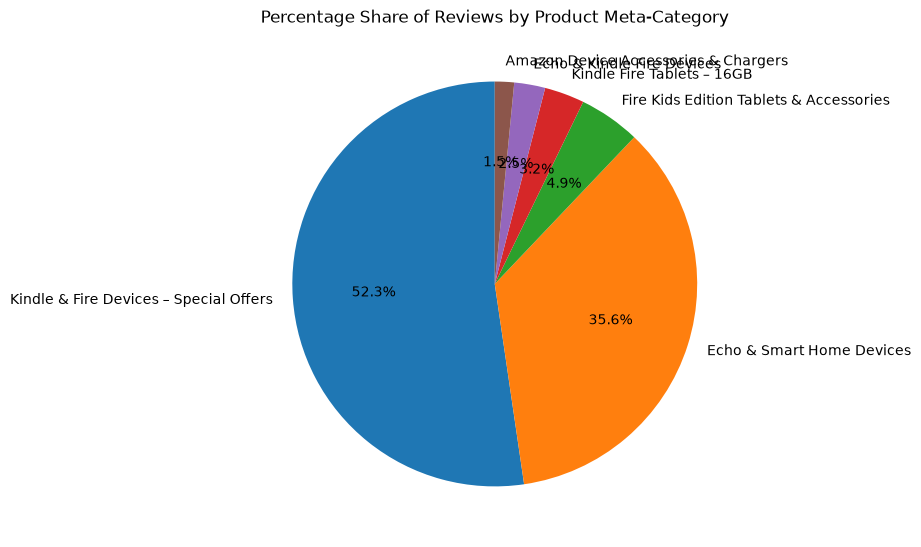

In [38]:
# GRAPH 2 — Share of Reviews by Product Meta-Category

category_counts = df_clustered["meta_category"].value_counts()

category_percent = (
    category_counts / category_counts.sum() * 100
)

plt.figure(figsize=(9, 9))

plt.pie(
    category_percent.values,
    labels=category_percent.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Percentage Share of Reviews by Product Meta-Category")

plt.tight_layout()
plt.show()

## Conclusion

The clustering analysis identified six meaningful product meta-categories from 34,614 Amazon reviews, with K = 6 providing the best clustering quality and creating a useful product-category structure for subsequent sentiment analysis.

##  Save the final Task 2 clustering model

In [43]:

import joblib
import sklearn
from pathlib import Path

# Create models directory if it doesn't already exist
models_dir = Path("../models")
models_dir.mkdir(parents=True, exist_ok=True)

# Store everything needed for future predictions
clustering_model = {
    "metadata_vectorizer": metadata_vectorizer,
    "review_vectorizer": review_vectorizer,
    "metadata_weight": METADATA_WEIGHT,
    "review_weight": REVIEW_WEIGHT,
    "svd": svd,
    "normalizer": normalizer,
    "kmeans": final_kmeans,
    "cluster_names": cluster_names
}

# Save the complete clustering pipeline
MODEL_PATH = models_dir / "product_clustering_model.pkl"

joblib.dump(
    clustering_model,
    MODEL_PATH
)

print("Product Clustering model saved successfully.")
print("Model path:", MODEL_PATH)
print("scikit-learn version:", sklearn.__version__)
print("Number of clusters:", final_kmeans.n_clusters)
print("Cluster names:", cluster_names)

Product Clustering model saved successfully.
Model path: ..\models\product_clustering_model.pkl
scikit-learn version: 1.9.1
Number of clusters: 6
Cluster names: {0: 'Kindle Fire Tablets – 16GB', 1: 'Fire Kids Edition Tablets & Accessories', 2: 'Echo & Kindle Fire Devices', 3: 'Kindle & Fire Devices – Special Offers', 4: 'Amazon Device Accessories & Chargers', 5: 'Echo & Smart Home Devices'}
